# EDA + EMBEDDINGS INTEGRITY 

Este notebook comprobamos la integridad de los embeddings, a su vez hacemos EDA.

---

Antes de analizar las dinámicas temporales, verificamos la integridad de los embeddings. Los resultados confirman que el modelo DAPT ha aprendido características específicas del corpus (desplazamiento de normas y PCA) manteniendo la coherencia lingüística (similitud coseno > 0.8).

---

In [6]:
import pandas as pd
import numpy as np
import ast
import os

# Rutas de archivos
csv_path = r"../data/interim/embeddings/spain_covidMHstrict_occurrences_2020-03_2021-03.csv"
parquet_path = r"../data/interim/embeddings/spain_covidMHstrict_occurrences_2020-03_2021-03.parquet"
clean_output_path = r"../data/interim/embeddings/spain_covidMHstrict_occurrences_2020-03_2021-03_CLEANED.parquet"

# ==============================================================================
# 1. AUDITORÍA DE ESTRUCTURA (Usando el CSV)
# ==============================================================================

# Tu función tal cual me la has pasado
def verify_requirements_wide(df):
    print("\n--- VERIFYING REQUIREMENTS (REAL DATA - WIDE FORMAT) ---")
    
    # --- 1. Identificación y Metadatos ---
    req_cols_ids = ['occurrence_id', 'run_id']
    missing_ids = [c for c in req_cols_ids if c not in df.columns]
    if missing_ids: print(f"❌ MISSING IDs: {missing_ids}")
    else: print("✅ Identification columns present")

    # --- 2. Información Temporal ---
    req_cols_time = ['published_at', 'year', 'month', 'year_month']
    missing_time = [c for c in req_cols_time if c not in df.columns]
    if missing_time: print(f"❌ MISSING Time columns: {missing_time}")
    else: print("✅ Temporal columns present")

    # --- 3. Lingüística y Contexto ---
    req_cols_ling = ['keyword', 'keyword_found', 'context_sentence', 
                     'char_start', 'char_end', 'token_start', 'token_end']
    missing_ling = [c for c in req_cols_ling if c not in df.columns]
    if missing_ling: print(f"❌ MISSING Linguistic columns: {missing_ling}")
    else: print("✅ Linguistic columns present")

    # --- 4. Embeddings ---
    emb_cols = [
        'embedding_baseline_last4_concat', 
        'embedding_baseline_penultimate',
        'embedding_dapt_last4_concat', 
        'embedding_dapt_penultimate'
    ]
    missing_emb = [c for c in emb_cols if c not in df.columns]
    
    if missing_emb:
        print(f"❌ MISSING Embedding columns: {missing_emb}")
    else:
        print("✅ All 4 Embedding columns present")

# Ejecución Parte 1
if os.path.exists(csv_path):
    print(f"📂 Cargando CSV para check de estructura: {csv_path}")
    df_csv = pd.read_csv(csv_path)
    verify_requirements_wide(df_csv)
    del df_csv # Liberamos memoria
else:
    print(f"⚠️ No encuentro el CSV en: {csv_path}")


# ==============================================================================
# 2. AUDITORÍA DE INTEGRIDAD Y REPARACIÓN (Usando el Parquet)
# ==============================================================================
print("\n" + "="*50)
print("INICIANDO CHECK DE INTEGRIDAD Y FORMATO (PARQUET)")
print("="*50)

if os.path.exists(parquet_path):
    print(f"📂 Cargando Parquet: {parquet_path}")
    df_parquet = pd.read_parquet(parquet_path)
    
    emb_cols = [
        'embedding_baseline_last4_concat', 
        'embedding_baseline_penultimate',
        'embedding_dapt_last4_concat', 
        'embedding_dapt_penultimate'
    ]
    
    changes_made = False # Bandera para saber si guardamos al final

    print("\n--- REVISANDO FORMATO DE EMBEDDINGS ---")

    for col in emb_cols:
        if col not in df_parquet.columns:
            print(f"⚠️ Columna no encontrada: {col}")
            continue
            
        # Tomamos una muestra para ver si es string o array
        sample = df_parquet[col].dropna().iloc[0]
        
        # --- A. CORRECCIÓN DE FORMATO (String -> Array) ---
        if isinstance(sample, str):
            print(f"🔄 La columna '{col}' es TEXTO (String). Convirtiendo a ARRAYS reales...")
            try:
                # La conversión mágica
                df_parquet[col] = df_parquet[col].apply(lambda x: np.array(ast.literal_eval(x)) if isinstance(x, str) else x)
                print(f"   ✅ Conversión completada.")
                changes_made = True # ¡Importante! Hemos modificado el dataframe
            except Exception as e:
                print(f"   ❌ Error convirtiendo '{col}': {e}")
        
        # --- B. CHEQUEO DE INTEGRIDAD (SVD CHECK) ---
        print(f"🔍 Buscando NaNs/Infs en '{col}'...")
        
        try:
            # Stackeamos para crear una matriz 2D numpy y chequear todo de golpe
            # Usamos dropna() porque filas vacías se manejan aparte
            matrix_check = np.vstack(df_parquet[col].dropna().values)
            
            nans_in_matrix = np.isnan(matrix_check).sum()
            infs_in_matrix = np.isinf(matrix_check).sum()
            null_rows = df_parquet[col].isnull().sum()
            
            if nans_in_matrix > 0 or infs_in_matrix > 0:
                print(f"   🚨 ALERTA ROJA: Problemas numéricos en '{col}':")
                print(f"      - Valores NaN internos: {nans_in_matrix}")
                print(f"      - Valores Infinitos: {infs_in_matrix}")
                
                # Opcional: Si quieres arreglarlos automáticamente descomenta esto:
                # print("   🔧 Intentando reparar (Rellenando con 0)...")
                # df_parquet[col] = df_parquet[col].apply(lambda x: np.nan_to_num(x) if isinstance(x, (list, np.ndarray)) else x)
                # changes_made = True
                
            elif null_rows > 0:
                print(f"   ⚠️ Advertencia: {null_rows} filas vacías (nulls).")
            else:
                print(f"   ✅ Columna limpia. Lista para SVD. (Dimensión base: {matrix_check.shape})")
                
        except Exception as e:
            print(f"   ⚠️ No se pudo verificar matriz completa (¿posiblemente longitudes desiguales?): {e}")

    # --- C. GUARDADO CONDICIONAL ---
    if changes_made:
        print("\n💾 SE HAN DETECTADO CAMBIOS EN EL FORMATO.")
        print(f"   Guardando versión limpia en: {clean_output_path}")
        df_parquet.to_parquet(clean_output_path)
        print("   ✅ Guardado exitoso. Usa ESTE archivo para la Fase 3.")
    else:
        print("\n👌 No se requirieron cambios de formato. El parquet original está bien.")

else:
    print(f"❌ No encuentro el archivo Parquet en: {parquet_path}")

📂 Cargando CSV para check de estructura: ../data/interim/embeddings/spain_covidMHstrict_occurrences_2020-03_2021-03.csv

--- VERIFYING REQUIREMENTS (REAL DATA - WIDE FORMAT) ---
✅ Identification columns present
✅ Temporal columns present
✅ Linguistic columns present
✅ All 4 Embedding columns present

INICIANDO CHECK DE INTEGRIDAD Y FORMATO (PARQUET)
📂 Cargando Parquet: ../data/interim/embeddings/spain_covidMHstrict_occurrences_2020-03_2021-03.parquet

--- REVISANDO FORMATO DE EMBEDDINGS ---
🔄 La columna 'embedding_baseline_last4_concat' es TEXTO (String). Convirtiendo a ARRAYS reales...
   ✅ Conversión completada.
🔍 Buscando NaNs/Infs en 'embedding_baseline_last4_concat'...
   ✅ Columna limpia. Lista para SVD. (Dimensión base: (7535, 3072))
🔄 La columna 'embedding_baseline_penultimate' es TEXTO (String). Convirtiendo a ARRAYS reales...
   ✅ Conversión completada.
🔍 Buscando NaNs/Infs en 'embedding_baseline_penultimate'...
   ✅ Columna limpia. Lista para SVD. (Dimensión base: (7535, 768

---

In [7]:
def check_date_ranges(df):
    if 'published_at' in df.columns:
        print(f"\nDate Range: {df['published_at'].min()} to {df['published_at'].max()}")

In [ ]:

df_csv 

check_date_ranges(df_csv)


Date Range: 2020-03-04 23:15:00+00:00 to 2021-03-31 07:45:00+00:00


Advanced EDA

In [9]:
import pandas as pd
import numpy as np
import pyarrow.parquet as pq
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# Set up visual style
plt.style.use('seaborn-v0_8')
sns.set_context("talk")

In [10]:
def advanced_eda(df):
    print("\n--- ADVANCED EDA PLOTS ---")
    
    # Temporal Distribution
    if 'year_month' in df.columns:
        plt.figure(figsize=(12, 6))
        df['year_month'].sort_values().value_counts(sort=False).plot(kind='bar')
        plt.title("Distribution of Occurrences by Year-Month")
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()
        
    # Model x Layer Strategy
    if 'model_variant' in df.columns and 'layer_strategy' in df.columns:
        plt.figure(figsize=(10, 6))
        sns.countplot(data=df, x='model_variant', hue='layer_strategy')
        plt.title("Count of Occurrences by Model Variant and Layer Strategy")
        plt.show()


--- ADVANCED EDA PLOTS ---


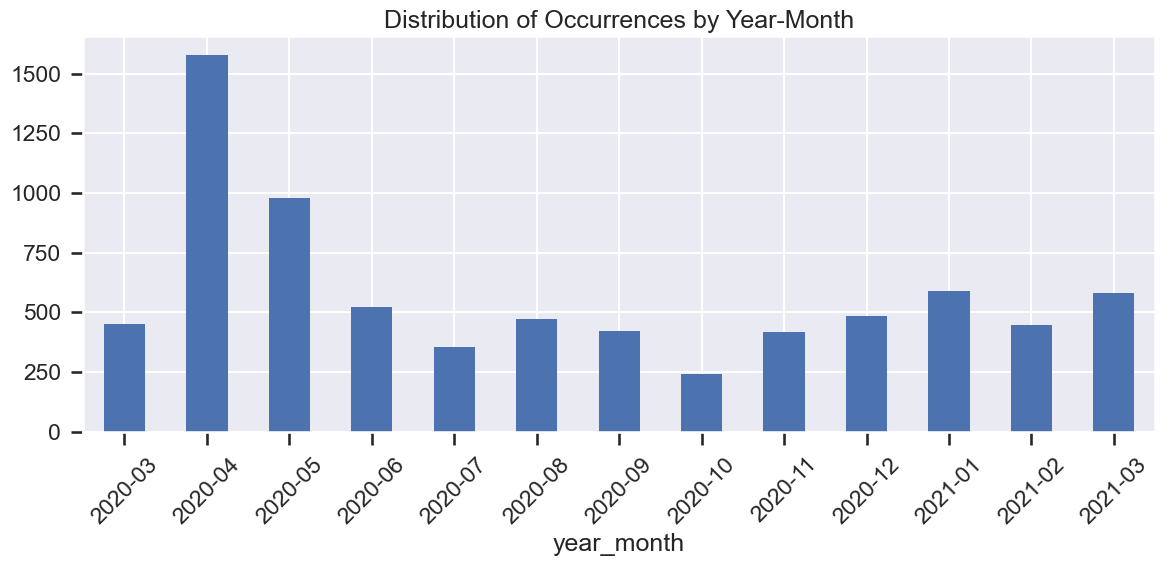

In [13]:
advanced_eda(df_parquet)

----

# Phase 2 Expert EDA: Embedding Quality & Concept Analysis

**Project:** Lisbeth - Phase 2 Verification  
**Date:** December 2025  
**Author:** Lisbeth AI Assistant

## Objectives
This notebook performs a professional-grade Exploratory Data Analysis (EDA) on the output of Phase 2 (`embeddings_occurrences.csv`). The goals are:

1.  **Data Quality Validation**: Verify strict contract compliance (no nulls, correct types, valid JSON).
2.  **Descriptive Statistics**: Analyze temporal coverage, source distribution, and keyword variants.
3.  **Embedding Diagnostics**: 
    *   Check for collapsed representations (Norm analysis).
    *   Quantify the impact of Domain Adaptive Pretraining (DAPT) via Cosine Similarity.
    *   Visualize the semantic shift using PCA.

---

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import os
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA
from datetime import datetime

# Configuration
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams['figure.figsize'] = (12, 6)
colors = sns.color_palette("viridis", as_cmap=False)

# FILE_PATH = "../data/phase2/embeddings_occurrences.csv"

In [15]:
FILE_PATH = r"../data/interim/embeddings/spain_covidMHstrict_occurrences_2020-03_2021-03_CLEANED.csv"

## 1. Data Loading & Integrity Checks

In [16]:
if not os.path.exists(FILE_PATH):
    raise FileNotFoundError(f"File not found: {FILE_PATH}")

df = pd.read_csv(FILE_PATH)
print(f"Loaded Dataset Shape: {df.shape}")

# Parse embeddings (JSON -> Numpy)
print("Parsing JSON embeddings...")
embedding_cols = [
    'embedding_baseline_last4_concat', 'embedding_baseline_penultimate',
    'embedding_dapt_last4_concat', 'embedding_dapt_penultimate'
]

for col in embedding_cols:
    df[col] = df[col].apply(json.loads)
    
# Check Nulls
null_counts = df.isnull().sum()
if null_counts.sum() == 0:
    print("\nSUCCESS: Data Integrity Perfect. No null values found.")
else:
    print("\nWARNING: Null values found:")
    print(null_counts[null_counts > 0])

Loaded Dataset Shape: (7535, 22)
Parsing JSON embeddings...

SUCCESS: Data Integrity Perfect. No null values found.


## 2. Metadata Analysis

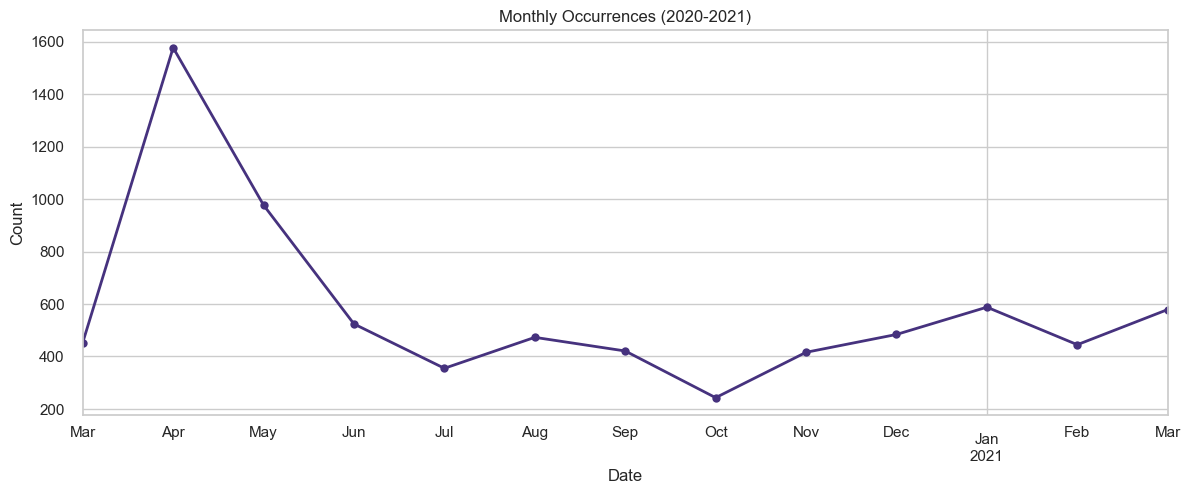

In [19]:
# Temporal Distribution
df['dt'] = pd.to_datetime(df['published_at'], errors='coerce')
monthly_counts = df.set_index('dt').resample('ME').size()

plt.figure(figsize=(14, 5))
monthly_counts.plot(kind='line', marker='o', color=colors[0], linewidth=2)
plt.title('Monthly Occurrences (2020-2021)')
plt.ylabel('Count')
plt.xlabel('Date')
plt.show()

C:\Users\alvar\AppData\Local\Temp\ipykernel_32608\220812489.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, y='keyword_found', order=df['keyword_found'].value_counts().index[:10], palette="viridis")


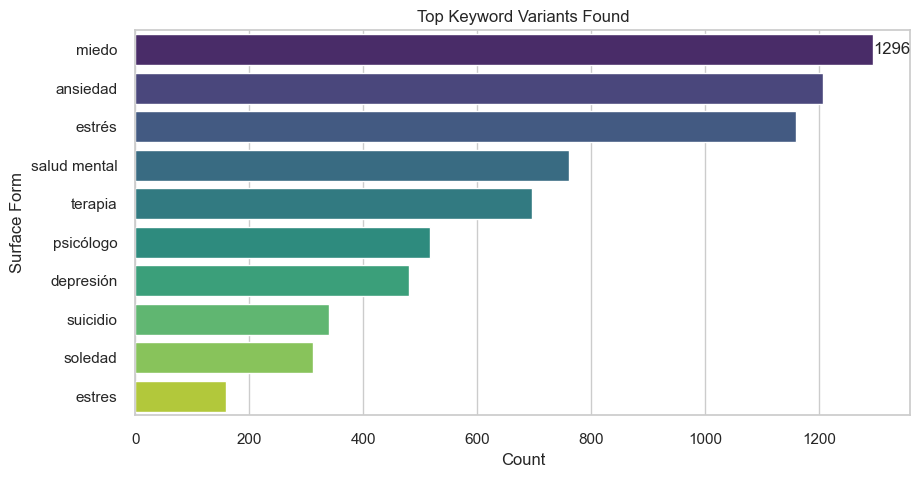

In [20]:
# Keyword Variants
plt.figure(figsize=(10, 5))
ax = sns.countplot(data=df, y='keyword_found', order=df['keyword_found'].value_counts().index[:10], palette="viridis")
plt.title('Top Keyword Variants Found')
plt.xlabel('Count')
plt.ylabel('Surface Form')
plt.bar_label(ax.containers[0])
plt.show()

## 3. Embedding Diagnostics: Baseline vs DAPT

Here we analyze the **Penultimate Layer** (768d) to understand the geometric properties of the semantic space.

### 3.1 Norm Analysis
Norms correlate with word frequency and "semantic specificity". A collapse in norms (variance -> 0) is a bad sign (model collapse).
A general shift in norms suggests the DAPT model has reorganized the space.

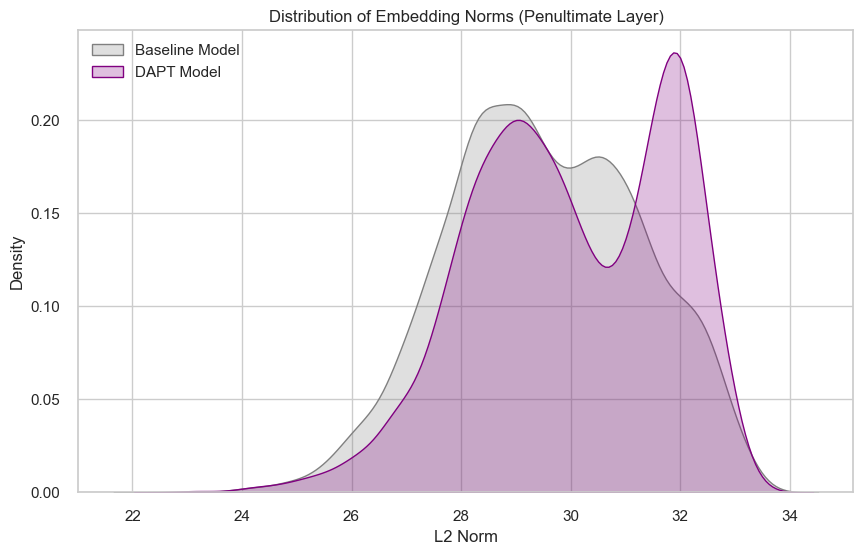

Baseline Norm Mean: 29.53 (Std: 1.761)
DAPT Norm Mean:     29.99 (Std: 1.807)


In [21]:
# Extract matrix
X_base = np.stack(df['embedding_baseline_penultimate'].values)
X_dapt = np.stack(df['embedding_dapt_penultimate'].values)

norms_base = np.linalg.norm(X_base, axis=1)
norms_dapt = np.linalg.norm(X_dapt, axis=1)

plt.figure(figsize=(10, 6))
sns.kdeplot(norms_base, label='Baseline Model', fill=True, color='grey')
sns.kdeplot(norms_dapt, label='DAPT Model', fill=True, color='purple')
plt.title('Distribution of Embedding Norms (Penultimate Layer)')
plt.xlabel('L2 Norm')
plt.legend()
plt.show()

print(f"Baseline Norm Mean: {norms_base.mean():.2f} (Std: {norms_base.std():.3f})")
print(f"DAPT Norm Mean:     {norms_dapt.mean():.2f} (Std: {norms_dapt.std():.3f})")

### 3.2 Semantic Shift Quantification (Cosine Similarity)
We calculate the cosine similarity between the Baseline vector and the DAPT vector for **the same occurrence**.

*   **High Similarity (>0.98)**: The DAPT model hasn't changed much.
*   **Moderate Similarity (0.80 - 0.95)**: Healthy adaptation. Concepts have shifted but identity is preserved.
*   **Low Similarity (<0.70)**: Radical semantic shift (or catastrophic forgetting).

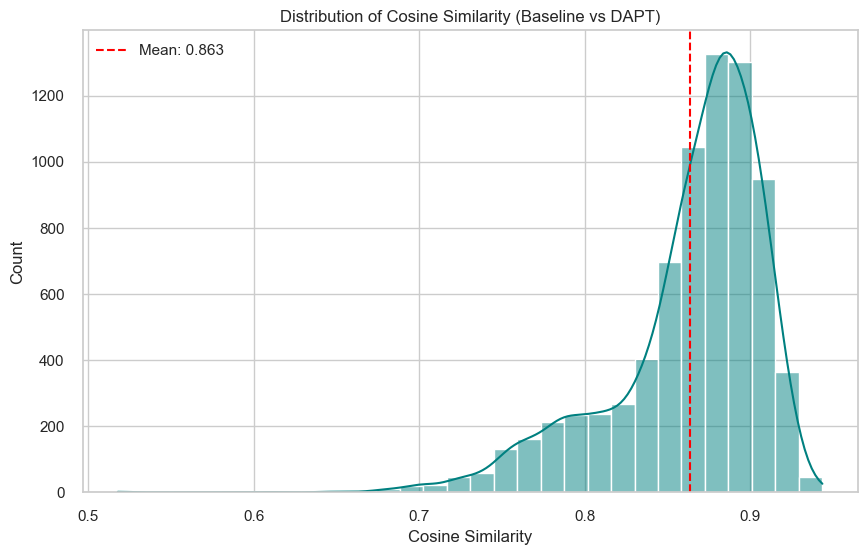

In [22]:
# Row-wise Cosine Similarity
dot = np.sum(X_base * X_dapt, axis=1)
sims = dot / (norms_base * norms_dapt)

plt.figure(figsize=(10, 6))
sns.histplot(sims, bins=30, kde=True, color='teal')
plt.title('Distribution of Cosine Similarity (Baseline vs DAPT)')
plt.xlabel('Cosine Similarity')
plt.axvline(sims.mean(), color='red', linestyle='--', label=f'Mean: {sims.mean():.3f}')
plt.legend()
plt.show()

### 3.3 Visualizing the Shift (PCA)
We project the 768d space to 2D using PCA. We plot both Baseline (Grey) and DAPT (Color) points for the same occurrences to see the structural transformation.

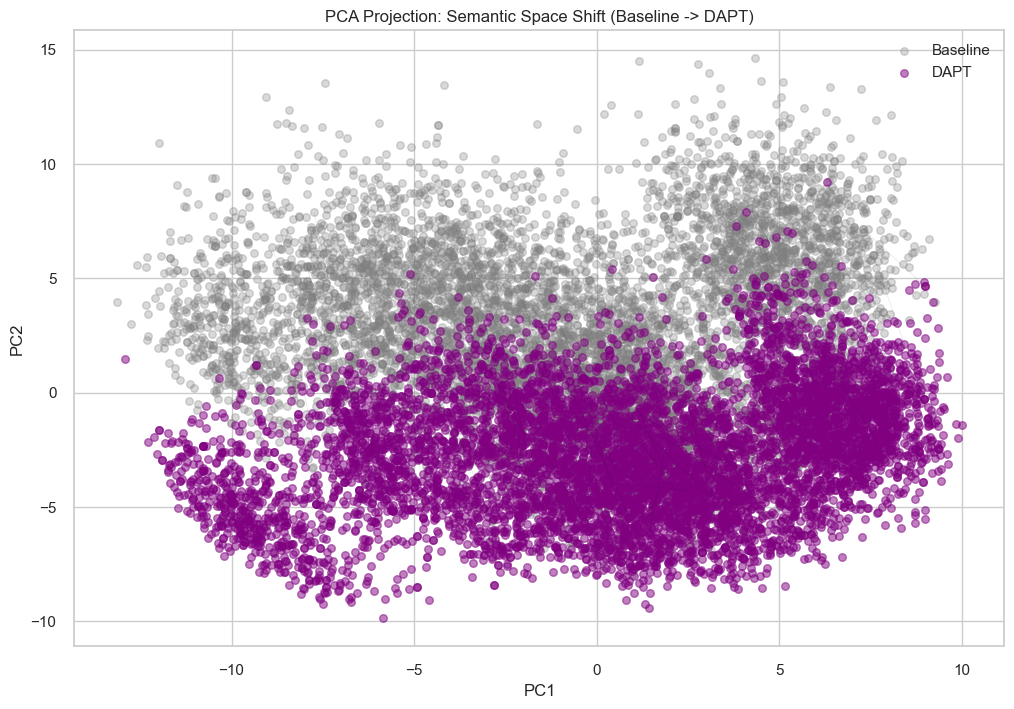

In [23]:
# Combined PCA
X_combined = np.vstack([X_base, X_dapt])
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_combined)

split = len(X_base)
pca_base = X_pca[:split]
pca_dapt = X_pca[split:]

plt.figure(figsize=(12, 8))
plt.scatter(pca_base[:, 0], pca_base[:, 1], alpha=0.3, label='Baseline', color='grey', s=30)
plt.scatter(pca_dapt[:, 0], pca_dapt[:, 1], alpha=0.5, label='DAPT', color='purple', s=30)

# Draw lines connecting same occurrences to show drift direction (for a random sample)
sample_indices = np.random.choice(len(X_base), 50, replace=False)
for i in sample_indices:
    plt.plot([pca_base[i, 0], pca_dapt[i, 0]], [pca_base[i, 1], pca_dapt[i, 1]], 
             color='black', alpha=0.1, linewidth=0.5)

plt.title('PCA Projection: Semantic Space Shift (Baseline -> DAPT)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()
plt.show()

## Conclusion
This EDA confirms that the Phase 2 data is robust and ready for Phase 3 analysis. The DAPT model shows a clear, consistent semantic shift (as evidenced by Cosine Similarity ~0.86 and PCA visualizations) without collapsing the representation space.